In [1]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, Activation,
    Rescaling, RandomFlip, RandomRotation, RandomZoom
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
print('All imports OK')

All imports OK


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Colab Notebooks/AI/FruitinAmazon.zip"
extract_dir = "FruitinAmazon"

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

dataset_root = os.path.join(extract_dir, 'FruitinAmazon')
train_dir    = os.path.join(dataset_root, 'train')
test_dir     = os.path.join(dataset_root, 'test')

print('Train dir exists:', os.path.isdir(train_dir))
print('Test  dir exists:', os.path.isdir(test_dir))

Train dir exists: True
Test  dir exists: True


In [6]:
class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

if not class_names:
    print('No class folders found – check your train_dir path!')
else:
    print(f'Found {len(class_names)} classes: {class_names}')


Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [7]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)
                os.remove(img_path)

if corrupted_images:
    print(f'Removed {len(corrupted_images)} corrupted images:')
    for p in corrupted_images:
        print(' ', p)
else:
    print('No corrupted images found.')

No corrupted images found.


In [8]:
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        class_counts[class_name] = len(images)

print('Class Distribution')
print('=' * 45)
print(f'{"Class Name":<25}{"Image Count":>15}')
print('=' * 45)
for name, count in class_counts.items():
    print(f'{name:<25}{count:>15}')
print('=' * 45)

Class Distribution
Class Name                   Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


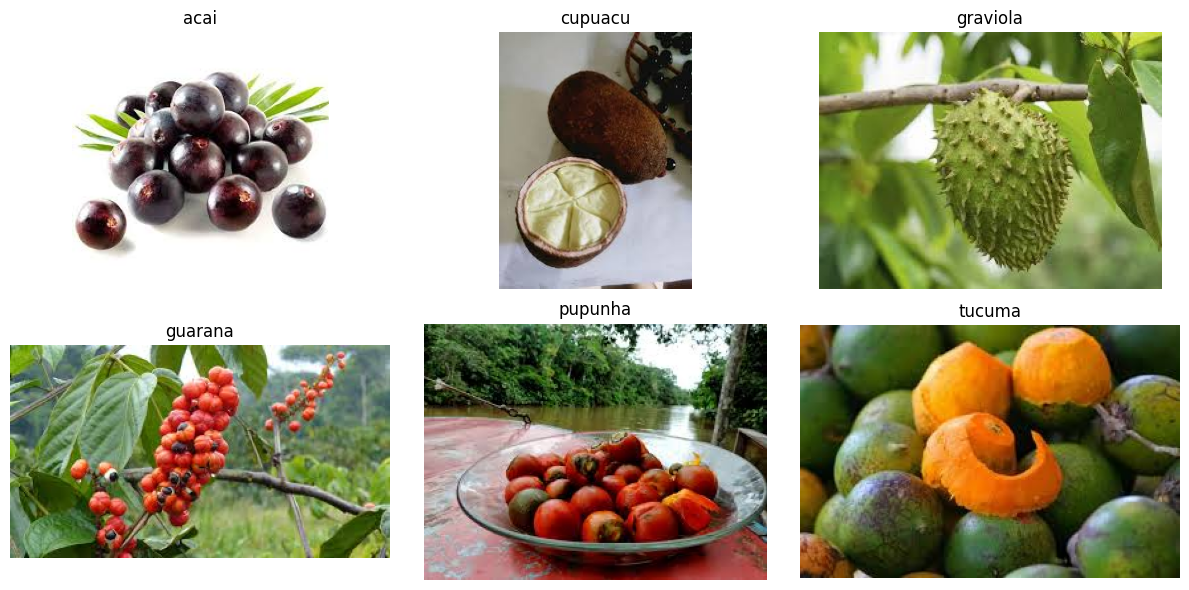

In [9]:
import matplotlib.image as mpimg

selected_images, selected_labels = [], []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            selected_images.append(os.path.join(class_path, random.choice(images)))
            selected_labels.append(class_name)

num_imgs = len(selected_images)
cols = (num_imgs + 1) // 2
fig, axes = plt.subplots(2, cols, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < num_imgs:
        ax.imshow(mpimg.imread(selected_images[i]))
        ax.set_title(selected_labels[i])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [10]:
img_height = 128
img_width  = 128
batch_size = 32
AUTOTUNE   = tf.data.AUTOTUNE

train_ds_raw, val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='both',
    seed=1337,
    image_size=(img_height, img_width),
    batch_size=batch_size,
)

class_names = train_ds_raw.class_names
num_classes = len(class_names)
print('Classes    :', class_names)
print('Num classes:', num_classes)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)
print('Test classes:', test_ds_raw.class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Classes    : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Num classes: 6
Found 30 files belonging to 6 classes.
Test classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


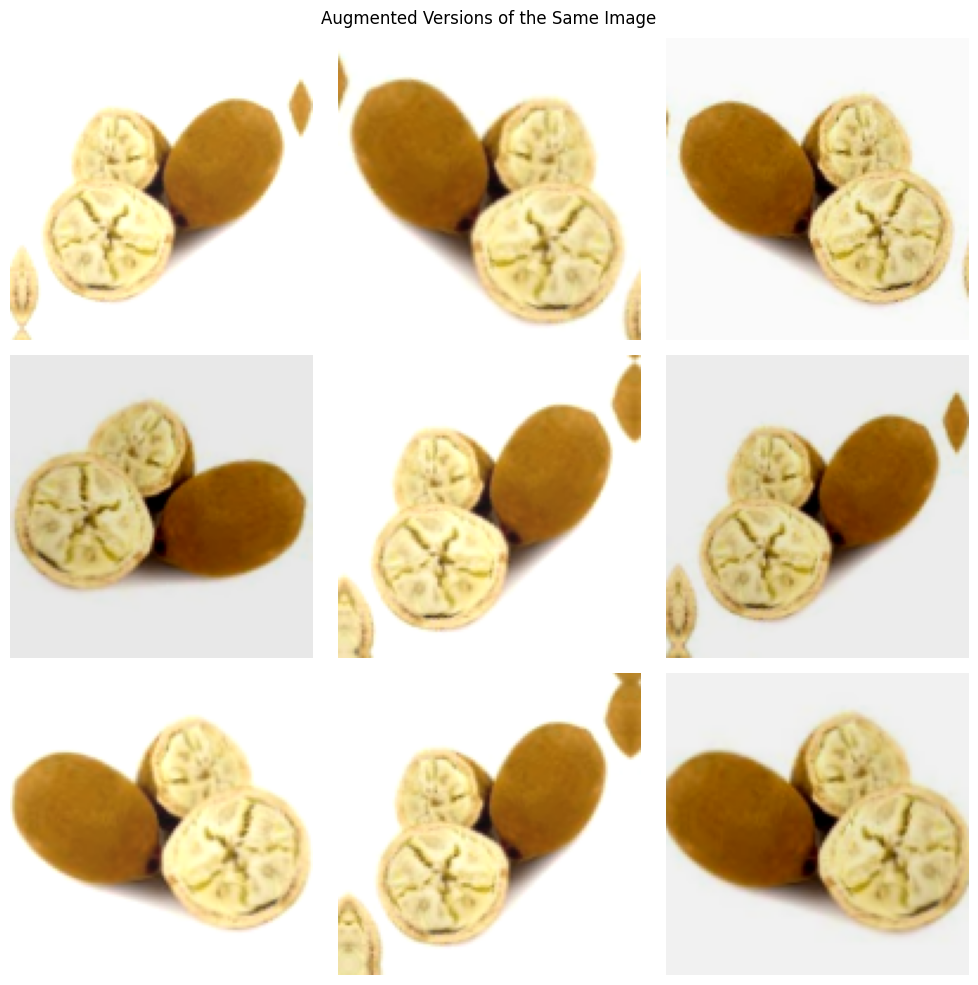

In [11]:
augmentation_layers = [
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
]

def augment(images):
    for layer in augmentation_layers:
        images = layer(images)
    return images

plt.figure(figsize=(10, 10))
for images, _ in train_ds_raw.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augment(images))[0].astype('uint8'))
        plt.axis('off')
plt.suptitle('Augmented Versions of the Same Image')
plt.tight_layout()

In [12]:
model = Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    # Augmentation (active only during training)
    RandomFlip('horizontal'),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # Normalise pixel values to [0, 1]
    Rescaling(1./255),

    # Conv Block 1
    Conv2D(32, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Conv Block 2
    Conv2D(64, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # Conv Block 3
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    # Fully-connected head
    Flatten(),
    Dense(256),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,485,574 (32.37 MB)

 Trainable params: 8,484,614 (32.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
# Cache & prefetch for speed
train_ds = train_ds_raw.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)

checkpoint_cb = ModelCheckpoint(
    'best_model_w6.h5',
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_accuracy',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reducelr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    epochs=50,
    validation_data=val_ds,
    callbacks=[checkpoint_cb, earlystop_cb, reducelr_cb]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1319 - loss: 2.5431   
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model_w6.h5



Epoch 1: finished saving model to best_model_w6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2083 - loss: 2.4577 - val_accuracy: 0.1667 - val_loss: 2.2482 - learning_rate: 0.0010
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4968 - loss: 1.4297   
Epoch 2: val_accuracy did not improve from 0.16667
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5278 - loss: 1.3240 - val_accuracy: 0.1667 - val_loss: 1.8034 - learning_rate: 0.0010
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6192 - loss: 1.0884
Epoch 3: val_accuracy improved from 0.16667 to 0.27778, saving model to best_model_w6.h5



Epoch 3: finished saving model to best_model_w6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6389 - loss: 0.9927 - val_accuracy: 0.2778 - val_loss: 1.7912 - learning_rate: 0.0010
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7147 - loss: 0.7611
Epoch 4: val_accuracy improved from 0.27778 to 0.33333, saving model to best_model_w6.h5



Epoch 4: finished saving model to best_model_w6.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.7222 - loss: 0.7204 - val_accuracy: 0.3333 - val_loss: 1.7660 - learning_rate: 0.0010
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7188 - loss: 0.6915
Epoch 5: val_accuracy did not improve from 0.33333
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7500 - loss: 0.6402 - val_accuracy: 0.2778 - val_loss: 1.7803 - learning_rate: 0.0010
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7697 - loss: 0.5957
Epoch 6: val_accuracy did not improve from 0.33333
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.7778 - loss: 0.6104 - val_accuracy: 0.2778 - val_loss: 1.8225 - learning_rate: 0.0010
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9380 - loss: 0.2306
Epoch 7: val_accuracy did not improve from 0.33333
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 3s/step - accuracy: 0.8889 - loss: 0.3214 - val_accuracy: 0.2778 - val_loss: 1.8679 - learning_rate: 0.0010
Epoch 8

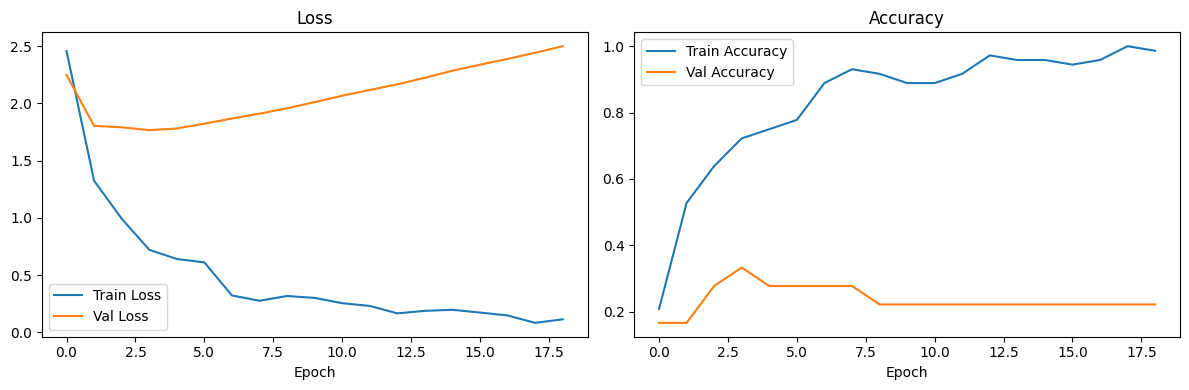

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
test_ds = test_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)

test_loss, test_acc = model.evaluate(test_ds)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.2333 - loss: 1.8555
Test Loss    : 1.8555
Test Accuracy: 0.2333


In [16]:
from sklearn.metrics import classification_report

predictions    = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=-1)
true_labels    = np.concatenate([y for _, y in test_ds], axis=0)

print(classification_report(true_labels, predicted_labels, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 698ms/step
              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.22      1.00      0.36         5
    graviola       0.00      0.00      0.00         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.29      0.40      0.33         5

    accuracy                           0.23        30
   macro avg       0.08      0.23      0.12        30
weighted avg       0.08      0.23      0.12        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
model.save('my_model_w6.keras')
print('Model saved as my_model_w6.keras')

Model saved as my_model_w6.keras


Transfer Learning with VGG16

In [18]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

# Load VGG16 without its top classification layers
base_model = VGG16(weights='imagenet', include_top=False,
                   input_shape=(img_height, img_width, 3))

# Freeze the pre-trained weights
for layer in base_model.layers:
    layer.trainable = False

# Add custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation='softmax')(x)

vgg_model = Model(inputs=base_model.input, outputs=output)

vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [19]:
vgg_history = vgg_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[earlystop_cb, reducelr_cb]
)

vgg_loss, vgg_acc = vgg_model.evaluate(test_ds)
print(f'VGG16 Transfer – Test Accuracy: {vgg_acc:.4f}')

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 7s/step - accuracy: 0.1389 - loss: 17.9672 - val_accuracy: 0.1667 - val_loss: 11.6672 - learning_rate: 0.0010
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.2917 - loss: 9.3544 - val_accuracy: 0.1667 - val_loss: 9.5475 - learning_rate: 0.0010
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 8s/step - accuracy: 0.5417 - loss: 3.9519 - val_accuracy: 0.3333 - val_loss: 7.3901 - learning_rate: 0.0010
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 8s/step - accuracy: 0.6806 - loss: 2.4456 - val_accuracy: 0.3333 - val_loss: 6.1436 - learning_rate: 0.0010
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7102 - loss: 1.6824
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 9s/step - accuracy: 0.6806 - loss: 2.2485 - val_accuracy: 0.4444 - val_loss: 6.2709 - learning_rate: 0.0010
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 6s/step - accuracy: 0.7500 - loss: 2.2920 - val_accuracy: 0.4444 - val_l

In [20]:
import numpy as np
from sklearn.metrics import classification_report

y_true_vgg, y_pred_vgg = [], []

for images, labels in val_ds:
    preds = vgg_model.predict(images, verbose=0)
    y_pred_vgg.extend(np.argmax(preds, axis=1))
    y_true_vgg.extend(labels.numpy())

y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)

unique_vgg     = sorted(np.unique(y_true_vgg))
vgg_names_used = [class_names[i] for i in unique_vgg]

print("=== VGG16 Transfer Learning — Classification Report ===\n")
print(classification_report(
    y_true_vgg, y_pred_vgg,
    labels=unique_vgg,
    target_names=vgg_names_used,
    zero_division=0
))


=== VGG16 Transfer Learning — Classification Report ===

              precision    recall  f1-score   support

        acai       0.33      0.33      0.33         3
     cupuacu       0.57      1.00      0.73         4
    graviola       0.50      1.00      0.67         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.50      0.50      0.50         4
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.44        18
   macro avg       0.32      0.47      0.37        18
weighted avg       0.32      0.44      0.37        18

